# ESG & Financial Performance Study

Econometric analysis examining the relationship between ESG (Environmental, Social, and Governance) ratings and financial performance across S&P 500 companies.

**Methods:** Pooled OLS with year fixed effects, Random Effects panel regression  
**Data:** S&P 500 annual returns (5 years) merged with firm-level ESG risk scores  
**Module:** Programming for Finance — MSc Finance & Financial Technology, Henley Business School

### Dependencies
```
pandas, numpy, yfinance, requests, statsmodels, linearmodels, matplotlib, seaborn, beautifulsoup4
```

## 1. Setup & Imports

In [1]:
from datetime import datetime, date
import os
import math

import pandas as pd
import numpy as np
import yfinance as yf
import requests
from requests.adapters import HTTPAdapter, Retry
from bs4 import BeautifulSoup
from io import StringIO, BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import RandomEffects

In [2]:
INDEX_CHOICE = "SP500"
YEARS_BACK = 5
MAX_TICKERS = 500
MAX_RETRIES = 4

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BROWSER_UA = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"

def build_http_session() -> requests.Session:
    session = requests.Session()
    retries = Retry(
        total=MAX_RETRIES,
        backoff_factor=0.7,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET", "HEAD"]
    )
    adapter = HTTPAdapter(max_retries=retries)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    session.headers.update({"User-Agent": BROWSER_UA})
    return session

HTTP = build_http_session()

## 2. Phase 1 — Define the Sample

Scrape current S&P 500 constituents from Wikipedia and define the time window (last 5 full calendar years).

In [3]:
def get_last_full_years(n_years: int) -> list:
    current_year = date.today().year
    last_full_year = current_year - 1
    return list(range(last_full_year - n_years + 1, last_full_year + 1))

def fetch_sp500_tickers() -> pd.DataFrame:
    HTTP = build_http_session()
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    response = HTTP.get(url)
    response.raise_for_status()

    soup = BeautifulSoup(response.content, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})

    if table is not None:
        df_list = pd.read_html(StringIO(str(table)))
        df = df_list[0].copy()
    else:
        try:
            tickers_list = yf.tickers_sp500()
            df = pd.DataFrame({"Symbol": tickers_list})
        except Exception:
            try:
                df = pd.read_html(StringIO(response.text))[0]
            except Exception:
                df = pd.read_html(BytesIO(response.content))[0]

    possible_symbol_cols = [c for c in df.columns if str(c).strip().lower() in ("symbol", "ticker", "tickers")]
    if not possible_symbol_cols:
        raise RuntimeError("Could not find a symbol/ticker column in the S&P 500 table.")

    sym_col = possible_symbol_cols[0]
    tickers = (
        df[sym_col].astype(str).str.strip()
        .str.replace(".", "-", regex=False)
    )
    out = pd.DataFrame({"ticker": tickers.dropna().unique()})
    return out[out["ticker"] != ""].reset_index(drop=True)

def get_universe() -> pd.DataFrame:
    universe = fetch_sp500_tickers()
    universe = universe.dropna(subset=["ticker"]).drop_duplicates()
    if MAX_TICKERS is not None:
        universe = universe.head(MAX_TICKERS)
    return universe.reset_index(drop=True)

In [4]:
years = get_last_full_years(YEARS_BACK)
print(f"Using last {YEARS_BACK} full calendar years: {years}")

universe_df = get_universe()
print(f"Universe size: {len(universe_df)} tickers")
universe_df.to_csv(os.path.join(OUTPUT_DIR, "universe_tickers.csv"), index=False)
tickers = universe_df['ticker'].tolist()

Using last 5 full calendar years: [2021, 2022, 2023, 2024, 2025]


Universe size: 500 tickers


## 3. Phase 2 — Data Collection

### 3a. Download Annual Returns
Fetch daily adjusted close prices via Yahoo Finance and compute calendar-year returns for each firm.

In [5]:
def compute_annual_returns(tickers: list, years: list) -> pd.DataFrame:
    start_date = f"{min(years)}-01-01"
    end_date = f"{max(years)}-12-31"

    price_panel = yf.download(
        tickers=tickers, start=start_date, end=end_date,
        progress=False, auto_adjust=False, group_by="ticker"
    )

    if isinstance(price_panel.columns, pd.MultiIndex):
        adj_close = price_panel.xs("Adj Close", axis=1, level=1, drop_level=False)
        adj_close.columns = adj_close.columns.get_level_values(0)
    else:
        adj_close = price_panel[['Adj Close']].copy()
        adj_close.columns = tickers

    adj_close = adj_close.dropna(axis=1, how='all')

    annual_returns_wide = adj_close.resample('YS').apply(
        lambda x: x.ffill().iloc[-1] / x.ffill().iloc[0] - 1
    )
    annual_returns_wide.index = annual_returns_wide.index.year
    annual_returns_wide = annual_returns_wide.loc[annual_returns_wide.index.isin(years)]

    annual_returns = annual_returns_wide.stack().reset_index()
    annual_returns.columns = ['year', 'ticker', 'annual_return']
    annual_returns = annual_returns[annual_returns['ticker'].isin(tickers)]
    annual_returns = annual_returns.dropna(subset=['annual_return'])

    return annual_returns.reset_index(drop=True)

In [6]:
print("Downloading prices and computing annual returns...")
annual_returns = compute_annual_returns(tickers, years)
print(f"Annual returns rows: {len(annual_returns)}")
annual_returns.to_csv(os.path.join(OUTPUT_DIR, "annual_returns.csv"), index=False)
annual_returns.head()

$FDXF: possibly delisted; no price data found  (1d 2021-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1767157200")



1 Failed download:


['FDXF']: possibly delisted; no price data found  (1d 2021-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1609477200, endDate = 1767157200")


Annual returns rows: 2463


,year,ticker,annual_return
0,2021,HIG,0.462913
1,2021,APH,0.373053
2,2021,PM,0.226880
3,2021,ECL,0.104312
4,2021,FRT,0.717167


### 3b. Load ESG Snapshot

Load pre-collected ESG risk scores. Scores are time-invariant firm characteristics replicated across all panel years.

In [7]:
def load_esg_snapshot(path):
    esg = pd.read_csv(path)
    esg.columns = esg.columns.str.strip().str.lower().str.replace(" ", "_")

    rename_map = {
        "total_score": "total_esg",
        "e_score": "env_score",
        "s_score": "soc_score",
        "g_score": "gov_score",
    }
    esg = esg.rename(columns=rename_map)

    required = {"ticker", "total_esg"}
    missing = required - set(esg.columns)
    if missing:
        raise ValueError(f"ESG snapshot missing required columns: {missing}")

    keep_cols = ["ticker", "total_esg", "env_score", "soc_score", "gov_score"]
    esg = esg[[c for c in keep_cols if c in esg.columns]]
    esg["ticker"] = esg["ticker"].astype(str).str.upper().str.replace(".", "-", regex=False)

    return esg

esg_df = load_esg_snapshot("SP500_esg_snapshot.csv")
esg_df = esg_df.drop_duplicates(subset="ticker")
print(f"Loaded ESG data for {esg_df['ticker'].nunique()} firms")
esg_df.head()

Loaded ESG data for 263 firms


,ticker,total_esg,env_score,soc_score,gov_score
0,BSX,32.98,3.16,18.00,11.83
2,EXR,13.94,3.81,4.28,5.86
3,ADM,36.36,16.38,14.20,5.90
6,BBY,11.92,2.11,5.20,4.60
7,AAPL,24.32,0.55,13.58,10.47


## 4. Panel Construction

Merge annual returns with ESG data, apply winsorisation to returns (1st/99th percentile), and reverse ESG risk scores so that higher values indicate better ESG performance.

In [8]:
def build_panel(annual_returns, esg_df, years):
    years_df = pd.DataFrame({"year": years})
    esg_df["_tmp"] = 1
    years_df["_tmp"] = 1
    esg_yearly = esg_df.merge(years_df, on="_tmp").drop(columns=["_tmp"])
    panel = annual_returns.merge(esg_yearly, on=["ticker", "year"], how="left")
    return panel

def winsorize_series(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lower=lo, upper=hi)

panel = build_panel(annual_returns, esg_df, years)
panel = panel.drop_duplicates(subset=["ticker", "year"])
panel = panel.dropna(subset=["total_esg"])

panel["annual_return_w"] = panel.groupby("year")["annual_return"].transform(
    lambda x: winsorize_series(x, 0.01, 0.99)
)
# Reverse ESG risk scores: higher = better ESG
panel["total_esg_pos"] = 50 - panel["total_esg"]

# Keep firms with at least 4 out of 5 years of data
counts = panel.groupby('ticker')['year'].nunique()
keep = counts[counts >= min(4, YEARS_BACK)].index
panel = panel[panel['ticker'].isin(keep)].reset_index(drop=True)

panel.to_csv(os.path.join(OUTPUT_DIR, "panel_dataset.csv"), index=False)
print(f"Final panel: {panel['ticker'].nunique()} firms, {len(panel)} observations")
print(f"Years covered: {sorted(panel['year'].unique())}")
panel.head()

Final panel: 240 firms, 1200 observations
Years covered: [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


,year,ticker,annual_return,total_esg,env_score,soc_score,gov_score,annual_return_w,total_esg_pos
0,2021,HIG,0.462913,20.73,1.45,8.58,10.93,0.462913,29.27
1,2021,ECL,0.104312,32.17,14.41,10.30,7.48,0.104312,17.83
2,2021,FRT,0.717167,16.98,4.10,5.80,7.12,0.717167,33.02
3,2021,SPGI,0.427217,13.39,1.41,5.86,6.11,0.427217,36.61
4,2021,SLB,0.388321,23.78,9.92,6.51,7.37,0.388321,26.22


## 5. Descriptive Statistics

In [9]:
desc_all = panel[["annual_return", "annual_return_w", "total_esg_pos"]].describe().T
print("Overall descriptive statistics:")
display(desc_all.round(4))

year_means = panel.groupby("year")[["annual_return_w", "total_esg_pos"]].mean().rename(
    columns={"annual_return_w": "Mean Annual Return (wins.)", "total_esg_pos": "Mean ESG Score"}
)
print("\nYearly means:")
display(year_means.round(4))

corr = panel[["annual_return_w", "total_esg_pos"]].corr()
print("\nPooled correlation:")
display(corr.round(4))

Overall descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
annual_return,1200.0,0.1460,0.3325,-0.6920,-0.0582,0.1121,0.3143,2.7792
annual_return_w,1200.0,0.1417,0.3080,-0.6078,-0.0582,0.1121,0.3143,1.5910
total_esg_pos,1200.0,25.1720,7.5703,5.2200,19.6625,26.1750,30.8875,42.6100



Yearly means:


,Mean Annual Return (wins.),Mean ESG Score
year,,
2021,0.3258,25.172
2022,-0.0739,25.172
2023,0.1889,25.172
2024,0.1315,25.172
2025,0.1364,25.172



Pooled correlation:


,annual_return_w,total_esg_pos
annual_return_w,1.0000,-0.0126
total_esg_pos,-0.0126,1.0000


## 6. Exploratory Visualisations

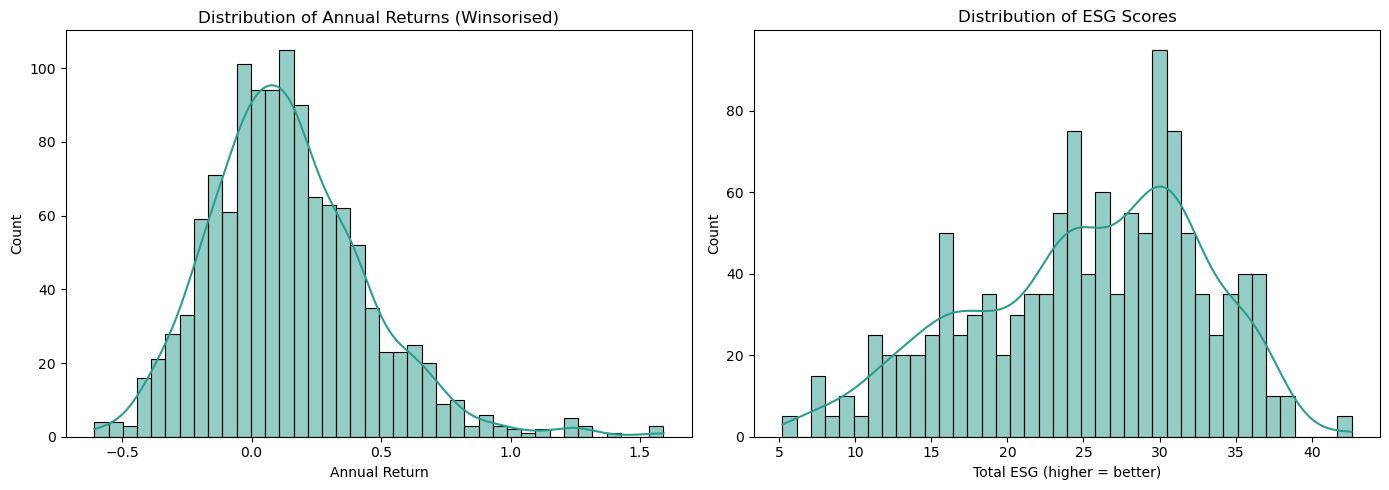

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(panel["annual_return_w"], kde=True, bins=40, color="#2a9d8f", ax=axes[0])
axes[0].set_title("Distribution of Annual Returns (Winsorised)")
axes[0].set_xlabel("Annual Return")

sns.histplot(panel["total_esg_pos"], kde=True, bins=40, color="#2a9d8f", ax=axes[1])
axes[1].set_title("Distribution of ESG Scores")
axes[1].set_xlabel("Total ESG (higher = better)")

plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches="tight")
plt.show()

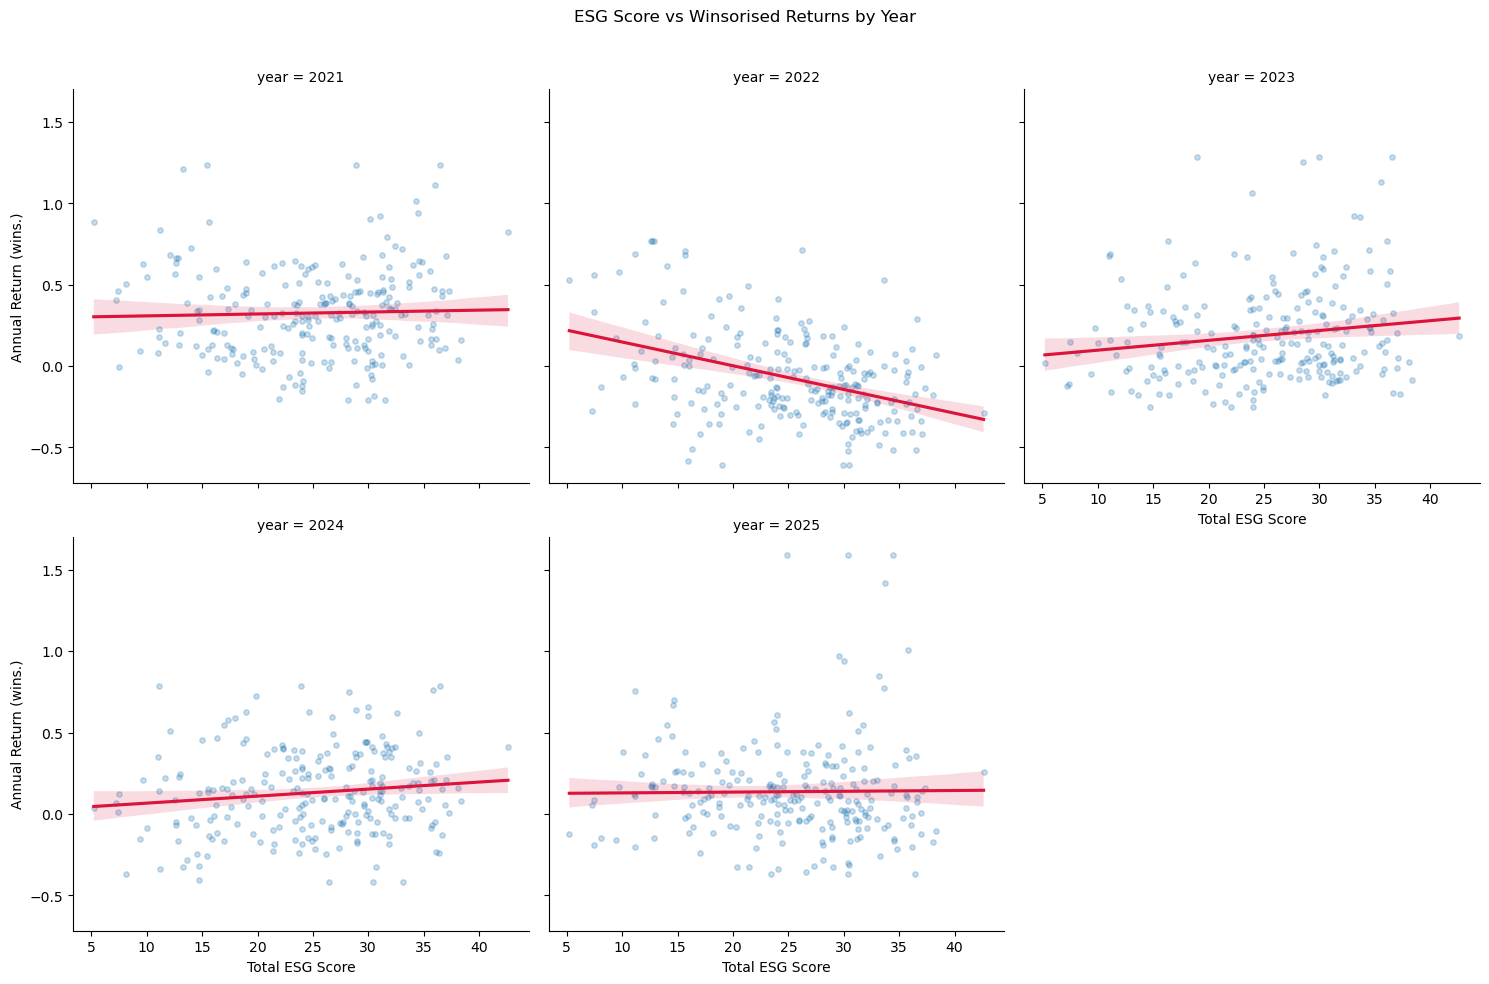

In [11]:
g = sns.lmplot(
    x="total_esg_pos", y="annual_return_w",
    col="year", col_wrap=3,
    data=panel, scatter_kws={"alpha": 0.25, "s": 15}, line_kws={"color": "crimson"}
)
g.set_axis_labels("Total ESG Score", "Annual Return (wins.)")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("ESG Score vs Winsorised Returns by Year")
plt.savefig("yearly_trendlines.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model 1 — Pooled OLS with Year Fixed Effects

Estimate the relationship between ESG scores and annual returns using pooled OLS with year fixed effects. Standard errors are clustered by firm to account for within-firm correlation.

In [12]:
formula_ols = "annual_return_w ~ total_esg_pos + C(year)"

ols_fe = smf.ols(formula=formula_ols, data=panel).fit(
    cov_type="cluster", cov_kwds={"groups": panel["ticker"]}
)

print(ols_fe.summary())

print(f"\n=== Model 1 Summary ===")
print(f"Coef(ESG+): {ols_fe.params.get('total_esg_pos', np.nan):.4f}")
print(f"SE(ESG+):   {ols_fe.bse.get('total_esg_pos', np.nan):.4f}")
print(f"t(ESG+):    {ols_fe.tvalues.get('total_esg_pos', np.nan):.2f}")
print(f"p(ESG+):    {ols_fe.pvalues.get('total_esg_pos', np.nan):.4f}")

                            OLS Regression Results                            
Dep. Variable:        annual_return_w   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     54.56
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.19e-37
Time:                        17:53:48   Log-Likelihood:                -173.63
No. Observations:                1200   AIC:                             359.3
Df Residuals:                    1194   BIC:                             389.8
Df Model:                           5                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3387      0.036     

## 8. Model 2 — Random Effects with Year Fixed Effects

Account for unobserved firm-level heterogeneity using a Random Effects estimator, with year dummies and firm-clustered standard errors.

In [13]:
panel_re = panel.set_index(["ticker", "year"]).copy()

x = pd.get_dummies(panel_re.reset_index()["year"], prefix="year", drop_first=True)
x.index = panel_re.index
x = pd.concat([pd.Series(1.0, index=panel_re.index, name="const"), panel_re["total_esg_pos"], x], axis=1)
y = panel_re["annual_return_w"]

re_model = RandomEffects(y, x)
re_res = re_model.fit(cov_type="clustered", cluster_entity=True)
print(re_res.summary)

print(f"\n=== Model 2 Summary ===")
print(f"Coef(ESG+):   {re_res.params.get('total_esg_pos', np.nan):.4f}")
print(f"StdErr(ESG+): {re_res.std_errors.get('total_esg_pos', np.nan):.4f}")

                        RandomEffects Estimation Summary                        
Dep. Variable:        annual_return_w   R-squared:                        0.1796
Estimator:              RandomEffects   R-squared (Between):              0.0009
No. Observations:                1200   R-squared (Within):               0.2141
Date:                Sat, Jun 27 2026   R-squared (Overall):              0.1748
Time:                        17:53:48   Log-likelihood                   -153.64
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      52.291
Entities:                         240   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                  F(5,1194)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             54.744
                            

## 9. Diagnostics

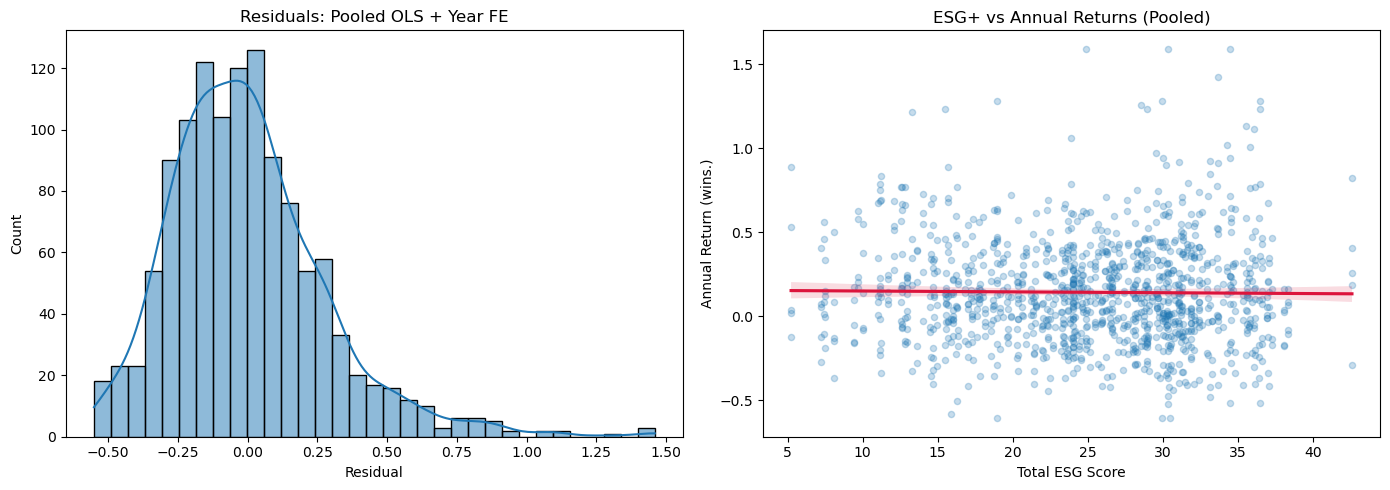

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
panel["_resid_ols1"] = ols_fe.resid
sns.histplot(panel["_resid_ols1"], kde=True, ax=axes[0])
axes[0].set_title("Residuals: Pooled OLS + Year FE")
axes[0].set_xlabel("Residual")

# ESG vs returns pooled scatter
sns.regplot(x="total_esg_pos", y="annual_return_w", data=panel,
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"color": "crimson"}, ax=axes[1])
axes[1].set_title("ESG+ vs Annual Returns (Pooled)")
axes[1].set_xlabel("Total ESG Score")
axes[1].set_ylabel("Annual Return (wins.)")

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()